Let's import the dataset at first.

In [64]:
import pandas as pd

train_url = "https://raw.githubusercontent.com/middlebury-csci-0451/CSCI-0451/main/data/palmer-penguins/train.csv"
train = pd.read_csv(train_url)

## 1. Explore

In this part, I'm going to construct some interesting displayed figures and interesting displayed tables. I will initiate a helpful discussion of both the figure and the table. 

Here's how the data looks:

In [65]:
train.head()

,studyName,Sample Number,Species,Region,Island,Stage,Individual ID,Clutch Completion,Date Egg,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Sex,Delta 15 N (o/oo),Delta 13 C (o/oo),Comments
0,PAL0708,27,Gentoo penguin (Pygoscelis papua),Anvers,Biscoe,"Adult, 1 Egg Stage",N46A1,Yes,11/29/07,44.5,14.3,216.0,4100.0,NaN,7.96621,-25.69327,NaN
1,PAL0708,22,Gentoo penguin (Pygoscelis papua),Anvers,Biscoe,"Adult, 1 Egg Stage",N41A2,Yes,11/27/07,45.1,14.5,215.0,5000.0,FEMALE,7.63220,-25.46569,NaN
2,PAL0910,124,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N67A2,Yes,11/16/09,41.4,18.5,202.0,3875.0,MALE,9.59462,-25.42621,NaN
3,PAL0910,146,Adelie Penguin (Pygoscelis adeliae),Anvers,Dream,"Adult, 1 Egg Stage",N82A2,Yes,11/16/09,39.0,18.7,185.0,3650.0,MALE,9.22033,-26.03442,NaN
4,PAL0708,24,Chinstrap penguin (Pygoscelis antarctica),Anvers,Dream,"Adult, 1 Egg Stage",N85A2,No,11/28/07,50.6,19.4,193.0,3800.0,MALE,9.28153,-24.97134,NaN


Before proceeding forward, I want to see the property of my features, such as if they are numeric or string.

In [66]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 275 entries, 0 to 274
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   studyName            275 non-null    object 
 1   Sample Number        275 non-null    int64  
 2   Species              275 non-null    object 
 3   Region               275 non-null    object 
 4   Island               275 non-null    object 
 5   Stage                275 non-null    object 
 6   Individual ID        275 non-null    object 
 7   Clutch Completion    275 non-null    object 
 8   Date Egg             275 non-null    object 
 9   Culmen Length (mm)   273 non-null    float64
 10  Culmen Depth (mm)    273 non-null    float64
 11  Flipper Length (mm)  273 non-null    float64
 12  Body Mass (g)        273 non-null    float64
 13  Sex                  265 non-null    object 
 14  Delta 15 N (o/oo)    262 non-null    float64
 15  Delta 13 C (o/oo)    263 non-null    flo

I also want to explore their distinct values.

In [67]:
cols = ['Region', 'Island', 'Stage', 'Clutch Completion', 'Date Egg', 'Sex', 'Comments']
for col in cols:
    print(train[col].unique())

['Anvers']
['Biscoe' 'Torgersen' 'Dream']
['Adult, 1 Egg Stage']
['Yes' 'No']
['11/29/07' '11/27/07' '11/16/09' '11/28/07' '11/10/08' '11/12/07'
 '11/23/09' '11/16/07' '11/4/08' '11/18/09' '11/19/07' '11/25/08'
 '11/17/09' '11/21/07' '11/9/08' '11/15/08' '11/7/08' '11/27/09'
 '11/18/07' '11/8/08' '11/11/08' '11/24/08' '11/21/09' '11/22/09'
 '11/2/08' '11/9/09' '11/15/09' '12/3/07' '11/26/07' '11/19/09' '11/6/08'
 '11/13/07' '11/9/07' '11/13/08' '11/10/09' '11/25/09' '11/20/09'
 '11/3/08' '11/30/07' '11/17/08' '11/12/09' '12/1/09' '11/10/07'
 '11/11/07' '11/22/07' '11/5/08' '11/15/07' '11/14/08' '11/14/09'
 '11/13/09']
[nan 'FEMALE' 'MALE' '.']
[nan 'Nest never observed with full clutch.'
 'No blood sample obtained for sexing.' 'Not enough blood for isotopes.'
 'Adult not sampled.' 'No blood sample obtained.'
 'Nest never observed with full clutch. Not enough blood for isotopes.'
 'Sexing primers did not amplify. Not enough blood for isotopes.']


We also want to explore all distinct values from those qualitative features. This will help us to choose proper features and draw corresponding tables. For example, as we can see the `Region` feature only has one distinct value, which might tell us that it is not worthwhile to take it into the consideration.

Then, I want to use the `seaborn` package to draw some interesting figures. I want to study if `Clutch Completion` will affect a penguin's `Body Mass`. Realizing penguin's sex  might also contribute the difference, I set `Sex` as another controlling variable.

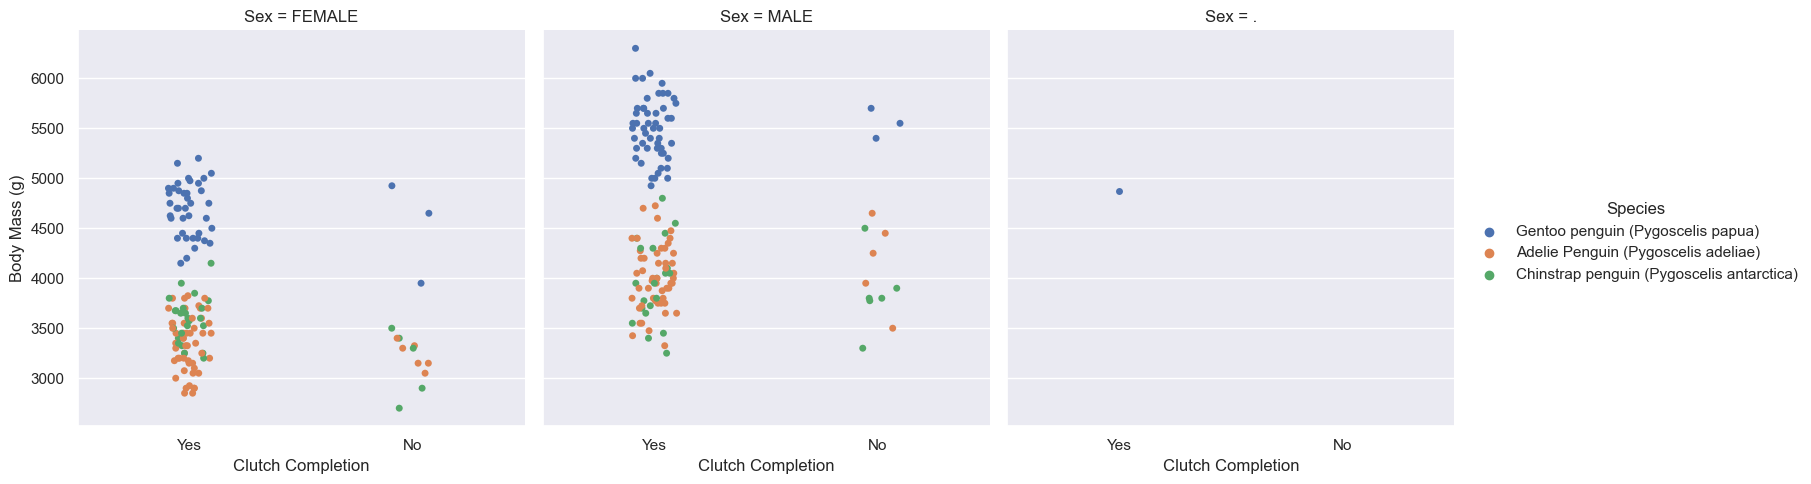

In [68]:
import seaborn as sns
import numpy as np

sns.set_theme()

sns.catplot(data=train, x="Clutch Completion", y="Body Mass (g)", hue="Species", col="Sex")

The graphs seem to tell that `Clutch Completion` doesn't have a strong relationship with the `Body Mass`. However, it is clear that male penguins tend to be heavier than female penguins.

Besides that, I want to study the quantitative features, `Delta 15 N (o/oo)` and `Delta 13 C (o/oo)`.

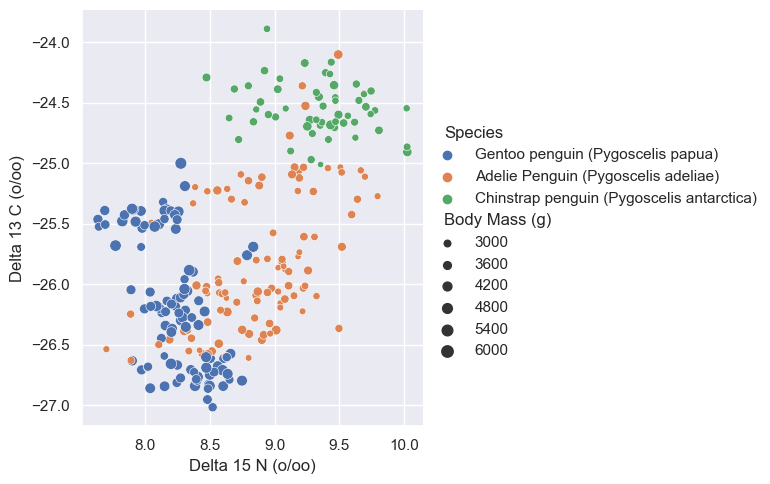

In [69]:
sns.relplot(data=train, x="Delta 15 N (o/oo)", y="Delta 13 C (o/oo)", hue="Species", size="Body Mass (g)")

It is relatively hard to tell, but it looks like most Gentoo penguins have more "negative" `Delta 13 C` and `Delta 15 N`, because we can see lots of blue dots are located in the lower left corner. In contrast, most Chinstrap penguins have more "positive" `Delta 13 C` and `Delta 15 N`.

We then want to construct some interesting tables.

In [70]:
train.groupby(["Species", "Island"]).size()

Species                                    Island   
Adelie Penguin (Pygoscelis adeliae)        Biscoe        35
                                           Dream         41
                                           Torgersen     42
Chinstrap penguin (Pygoscelis antarctica)  Dream         56
Gentoo penguin (Pygoscelis papua)          Biscoe       101
dtype: int64

From this table, we can see that all the Chinstrap penguins live in the Dream island and all the Gentoo penguins live in Biscoe island. However, the Adelie penguin lives in all three Islands, including Dream, Biscoe, and Torgersen.

In [71]:
train.groupby(["Species", "Island"])[["Body Mass (g)", "Flipper Length (mm)"]].aggregate([np.mean]).round(2)

Body Mass (g)  \
                                                             mean   
Species                                   Island                    
Adelie Penguin (Pygoscelis adeliae)       Biscoe          3648.57   
                                          Dream           3657.32   
                                          Torgersen       3692.68   
Chinstrap penguin (Pygoscelis antarctica) Dream           3717.86   
Gentoo penguin (Pygoscelis papua)         Biscoe          5119.50   

                                                    Flipper Length (mm)  
                                                                   mean  
Species                                   Island                         
Adelie Penguin (Pygoscelis adeliae)       Biscoe                 188.71  
                                          Dream                  189.63  
                                          Torgersen              191.37  
Chinstrap penguin (Pygoscelis antarctica) Dream                  195.46  
Gentoo penguin (Pygoscelis papua)         Biscoe                 217.65

We are comparing Body Mass and Flipper Length for different penguin species (across different islands). It seems the Gentoo penguin is heavier than the rest two species and also has longer Flipper. Also, as for the Adelie penguin, those which live in the Torgersen tend to have bigger body size and mass. 

## 2. Model

I will find three features of the data and a model trained on those features which achieves 100% testing accuracy. Among those three features, one will be qualitative (like `Island` or `Clutch Completion`), and the other two features will be quantitative (like `Body Mass (g)` or `Culmen Depth (mm)`).

At first, we need to do some data preparation, such as factoring those qualitative features.

In [72]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
le.fit(train["Species"])

def prepare_data(df):
  df = df.drop(["studyName", "Sample Number", "Individual ID", "Date Egg", "Comments", "Region"], axis = 1)
  df = df[df["Sex"] != "."]
  df = df.dropna()
  y = le.transform(df["Species"])
  df = df.drop(["Species"], axis = 1)
  df = pd.get_dummies(df)
  return df, y

X_train, y_train = prepare_data(train)

Here is how the training data looks like:

In [73]:
X_train.head()

,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Delta 15 N (o/oo),Delta 13 C (o/oo),Island_Biscoe,Island_Dream,Island_Torgersen,"Stage_Adult, 1 Egg Stage",Clutch Completion_No,Clutch Completion_Yes,Sex_FEMALE,Sex_MALE
1,45.1,14.5,215.0,5000.0,7.63220,-25.46569,1,0,0,1,0,1,1,0
2,41.4,18.5,202.0,3875.0,9.59462,-25.42621,0,0,1,1,0,1,0,1
3,39.0,18.7,185.0,3650.0,9.22033,-26.03442,0,1,0,1,0,1,0,1
4,50.6,19.4,193.0,3800.0,9.28153,-24.97134,0,1,0,1,1,0,0,1
5,33.1,16.1,178.0,2900.0,9.04218,-26.15775,0,1,0,1,0,1,1,0


After doing some preliminary analysis, I identified those features as the following:

- Qualitative Features: `Island`, `Clutch Completion`, and `Sex`;
- Quantitative Features: `Culmen Length (mm)`, `Culmen Depth (mm)`, `Flipper Length (mm)`, `Body Mass (g)`, `Delta 15 N (o/oo)`, and `Delta 13 C (o/oo)`.

I dropped the `Stage` feature because it only contains one distinct value, as shown above. Then I can use the `itertools` to produce all combinations of features. Now I'm going to pick the model for prediction. 

In [74]:
from itertools import combinations
from sklearn.linear_model import LogisticRegression 
from sklearn.model_selection import cross_val_score
import warnings
warnings.filterwarnings('ignore')

all_qual_cols = ["Island", "Clutch Completion", "Sex"]
all_quant_cols = ['Culmen Length (mm)', 'Culmen Depth (mm)', 'Flipper Length (mm)', 'Body Mass (g)', 'Delta 15 N (o/oo)', 'Delta 13 C (o/oo)']
LR = LogisticRegression()
result = {}

for qual in all_qual_cols: 
  qual_cols = [col for col in X_train.columns if qual in col ]
  for pair in combinations(all_quant_cols, 2):
    cols = qual_cols + list(pair)
    LR.fit(X_train[cols], y_train)

    # convert list to string
    feature = " ".join(str(col) for col in cols)

    # use cross-validation
    cv_scores = cross_val_score(LR, X_train[cols], y_train, cv=5)
    mean_score = cv_scores.mean()
    result[feature] = mean_score

    # just using the score
    #result[feature] = LR.score(X_train[cols], y_train)

    

In [75]:
result

{'Island_Biscoe Island_Dream Island_Torgersen Culmen Length (mm) Culmen Depth (mm)': 0.996078431372549,
 'Island_Biscoe Island_Dream Island_Torgersen Culmen Length (mm) Flipper Length (mm)': 0.92579185520362,
 'Island_Biscoe Island_Dream Island_Torgersen Culmen Length (mm) Body Mass (g)': 0.8475867269984917,
 'Island_Biscoe Island_Dream Island_Torgersen Culmen Length (mm) Delta 15 N (o/oo)': 0.9726998491704375,
 'Island_Biscoe Island_Dream Island_Torgersen Culmen Length (mm) Delta 13 C (o/oo)': 0.9568627450980391,
 'Island_Biscoe Island_Dream Island_Torgersen Culmen Depth (mm) Flipper Length (mm)': 0.8670437405731523,
 'Island_Biscoe Island_Dream Island_Torgersen Culmen Depth (mm) Body Mass (g)': 0.8475867269984917,
 'Island_Biscoe Island_Dream Island_Torgersen Culmen Depth (mm) Delta 15 N (o/oo)': 0.8398190045248869,
 'Island_Biscoe Island_Dream Island_Torgersen Culmen Depth (mm) Delta 13 C (o/oo)': 0.9060331825037707,
 'Island_Biscoe Island_Dream Island_Torgersen Flipper Length (mm) 

In [76]:
# from IPython.core.interactiveshell import InteractiveShell
# InteractiveShell.ast_node_interactivity = "all"
print("The best features are " + max(result, key = result.get))

The best features are Island_Biscoe Island_Dream Island_Torgersen Culmen Length (mm) Culmen Depth (mm)


Therefore, we con use those features to construct a model. I'm going to implement a support vector machine model (`svm`), but first, I need to prepare my test data.

In [77]:
test_url = "https://raw.githubusercontent.com/middlebury-csci-0451/CSCI-0451/main/data/palmer-penguins/test.csv"
test = pd.read_csv(test_url)

X_test, y_test = prepare_data(test)

# normalization
X_test_new =(X_test-X_train.mean())/X_train.std()
X_train_new =(X_train-X_train.mean())/X_train.std()

However, I also need to specify which parameters I'm going to choose.

In [78]:
cols = ['Culmen Depth (mm)', 'Culmen Length (mm)', 'Island_Biscoe', 'Island_Dream', 'Island_Torgersen']
from sklearn.svm import SVC

scores_gamma = {}
gammas = 10**np.arange(-5, 5, dtype=float)

for gamma in gammas:
    svm = SVC(gamma=gamma)
    svm.fit(X_train[cols], y_train)

    cv_scores = cross_val_score(svm, X_train[cols], y_train, cv=5)
    mean_score = cv_scores.mean()
    scores_gamma[gamma] = mean_score


scores_gamma

{1e-05: 0.41402714932126694,
 0.0001: 0.7616892911010558,
 0.001: 0.8790346907993968,
 0.01: 0.9805429864253394,
 0.1: 0.984389140271493,
 1.0: 0.9607843137254901,
 10.0: 0.7107088989441931,
 100.0: 0.5,
 1000.0: 0.4218702865761689,
 10000.0: 0.4218702865761689}

Text(0, 0.5, 'Accuracy')

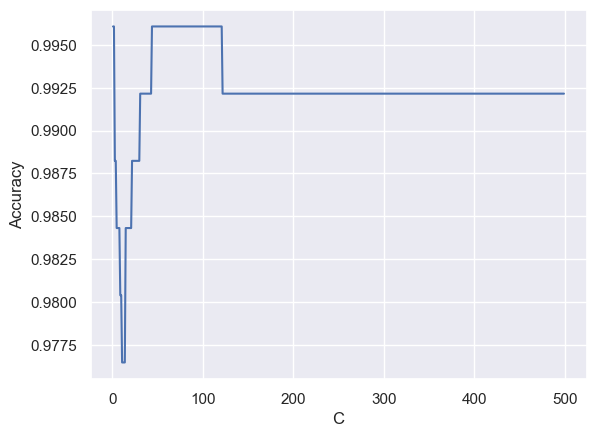

In [79]:
import matplotlib.pyplot as plt

scores_c = {}

Cs = np.arange(1, 500, 1)

for c in Cs:
    svm = SVC(gamma=max(scores_gamma, key = scores_gamma.get), C=c)
    svm.fit(X_train[cols], y_train)

    cv_scores = cross_val_score(svm, X_train_new[cols], y_train, cv=5)
    mean_score = cv_scores.mean()
    scores_c[c] = mean_score

lists = sorted(scores_c.items()) # sorted by key, return a list of tuples
x, y = zip(*lists) # unpack a list of pairs into two tuples

plt.plot(x, y)
plt.xlabel('C')
plt.ylabel('Accuracy')

It looks like when `Gamma` is 0.1 and `C` is 100, the model will achieve the highest accuracy. Thus, I will just take those as my argument.

In [80]:
%%capture
svm = SVC(gamma =0.1, C=100)
svm.fit(X_train_new[cols], y_train)

In [81]:
svm.score(X_test_new[cols], y_test)

1.0

We can see the `svm` model still achieves 100% accuracy on the unseen test data, so I will choose that as my final model.

## 3. Evaluate

Lastly, I will show the decision regions of my finished model, split out by the qualitative feature. Here I'm using the Island as the qualitative feature, which means there will be three different graphs.

In [82]:
from matplotlib.patches import Patch
from matplotlib import pyplot as plt
import numpy as np

def plot_regions(model, X, y):
    
    x0 = X[X.columns[0]]
    x1 = X[X.columns[1]]
    qual_features = X.columns[2:]
    
    fig, axarr = plt.subplots(1, len(qual_features), figsize = (7, 3))

    # create a grid
    grid_x = np.linspace(x0.min(),x0.max(),501)
    grid_y = np.linspace(x1.min(),x1.max(),501)
    xx, yy = np.meshgrid(grid_x, grid_y)
    
    XX = xx.ravel()
    YY = yy.ravel()

    for i in range(len(qual_features)):
      XY = pd.DataFrame({
          X.columns[0] : XX,
          X.columns[1] : YY
      })

      for j in qual_features:
        XY[j] = 0

      XY[qual_features[i]] = 1

      p = model.predict(XY)
      p = p.reshape(xx.shape)
      
      
      # use contour plot to visualize the predictions
      axarr[i].contourf(xx, yy, p, cmap = "jet", alpha = 0.2, vmin = 0, vmax = 2)
      
      ix = X[qual_features[i]] == 1
      # plot the data
      axarr[i].scatter(x0[ix], x1[ix], c = y[ix], cmap = "jet", vmin = 0, vmax = 2)
      
      axarr[i].set(xlabel = X.columns[0], 
            ylabel  = X.columns[1])
      
      patches = []
      for color, spec in zip(["red", "green", "blue"], ["Adelie", "Chinstrap", "Gentoo"]):
        patches.append(Patch(color = color, label = spec))

      plt.legend(title = "Species", handles = patches, loc = "best")
      
      plt.tight_layout()

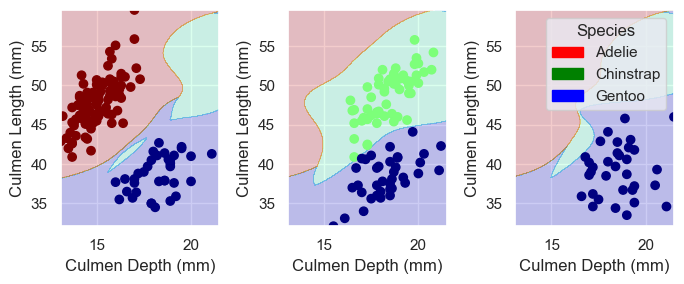

In [83]:
svm = SVC(C = 100, gamma = 0.1)
svm.fit(X_train[cols], y_train)
plot_regions(svm, X_train[cols], y_train)

These graphs are also intuitive, because we already know hat the Gentoo penguin lives in all three islands, and that's why we can see that there are blue dots in all three graphs. Besides, the use of Culmen Depth and Culmen Length largely improves our model's performance. Hence, our model can correctly classify different penguin species. 